# STEP 1: IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import re
import nltk

import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# STEP 2: LOAD DATASET

In [2]:


url = "https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/amazon.csv"

df = pd.read_csv(url)

print(df.head())



                                          reviewText  Positive
0  This is a one of the best apps acording to a b...         1
1  This is a pretty good version of the game for ...         1
2  this is a really cool game. there are a bunch ...         1
3  This is a silly game and can be frustrating, b...         1
4  This is a terrific game on any pad. Hrs of fun...         1


# STEP 3: DATA EXPLORATION

In [3]:


print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Distribution:")
print(df['Positive'].value_counts())


Dataset Shape:
(20000, 2)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reviewText  20000 non-null  object
 1   Positive    20000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 312.6+ KB
None

Missing Values:
reviewText    0
Positive      0
dtype: int64

Sentiment Distribution:
Positive
1    15233
0     4767
Name: count, dtype: int64


# STEP 4: VISUALIZATION

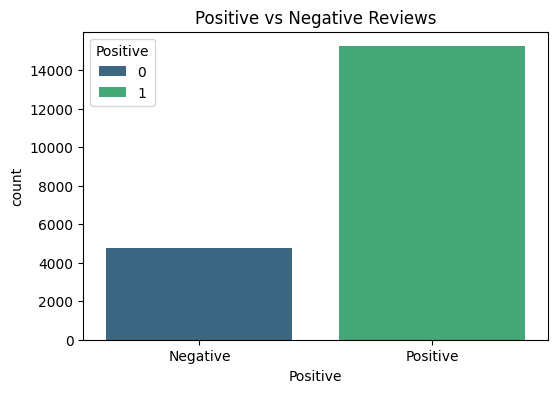

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Positive',
    data=df,
    hue='Positive',
    palette='viridis'
)

plt.title("Positive vs Negative Reviews")

plt.xticks([0,1], ["Negative", "Positive"])

plt.show()

# STEP 5: TEXT CLEANING

In [5]:


stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove stopwords
    text = ' '.join([
        word for word in text.split()
        if word not in stop_words
    ])

    return text


# Apply cleaning
df['Clean_Review'] = df['reviewText'].apply(clean_text)

print("\nCleaned Data:")
print(df[['reviewText', 'Clean_Review']].head())


Cleaned Data:
                                          reviewText  \
0  This is a one of the best apps acording to a b...   
1  This is a pretty good version of the game for ...   
2  this is a really cool game. there are a bunch ...   
3  This is a silly game and can be frustrating, b...   
4  This is a terrific game on any pad. Hrs of fun...   

                                        Clean_Review  
0  one best apps acording bunch people agree bomb...  
1  pretty good version game free lots different l...  
2  really cool game bunch levels find golden eggs...  
3  silly game frustrating lots fun definitely rec...  
4  terrific game pad hrs fun grandkids love great...  


# STEP 6: FEATURE EXTRACTIO

In [6]:


tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['Clean_Review'])

y = df['Positive']

# STEP 7: TRAIN TEST SPLIT

In [7]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# STEP 8: MODEL TRAINING

In [8]:


model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# STEP 9: MODEL EVALUATION

In [9]:
y_pred = model.predict(X_test)

print("\nAccuracy Score:")
print(f"{accuracy_score(y_test, y_pred):.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score:
0.89

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.65      0.74       958
           1       0.90      0.97      0.93      3042

    accuracy                           0.89      4000
   macro avg       0.88      0.81      0.84      4000
weighted avg       0.89      0.89      0.89      4000



# STEP 10: CONFUSION MATRIX

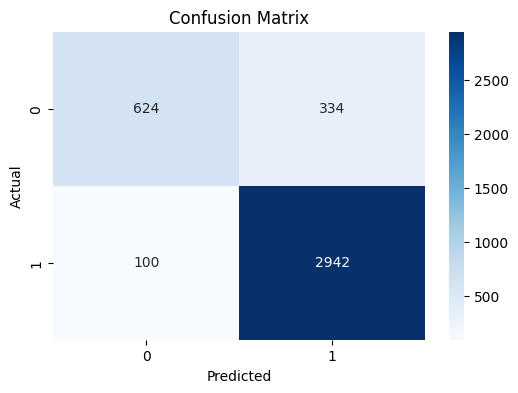

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


# STEP 11: REAL-TIME PREDICTION

In [11]:
def predict_sentiment(review):

    # Clean review
    cleaned_review = clean_text(review)

    # Convert into TF-IDF vector
    vector = tfidf.transform([cleaned_review])

    # Predict
    prediction = model.predict(vector)[0]

    if prediction == 1:
        return "Positive 😊"

    else:
        return "Negative 😡"


# STEP 12: TEST EXAMPLES


In [12]:
samples = [

    "The product is amazing and works perfectly",

    "This is the worst thing I bought",

    "Excellent quality and fantastic performance",

    "Terrible experience and waste of money",

    "I absolutely love this app",

    "Very disappointing and useless"
]

for review in samples:

    print("\nReview:", review)

    print("Prediction:", predict_sentiment(review))


Review: The product is amazing and works perfectly
Prediction: Positive 😊

Review: This is the worst thing I bought
Prediction: Negative 😡

Review: Excellent quality and fantastic performance
Prediction: Positive 😊

Review: Terrible experience and waste of money
Prediction: Negative 😡

Review: I absolutely love this app
Prediction: Positive 😊

Review: Very disappointing and useless
Prediction: Negative 😡
